**Daily Challenge: Classification with Neural Networks in TensorFlow**

TensorFlow Version: 2.18.0
X shape:  (1000, 2)
y shape:  (1000,)

First 5 samples of X (features):
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 samples of y (labels):
 [1 1 1 1 0]


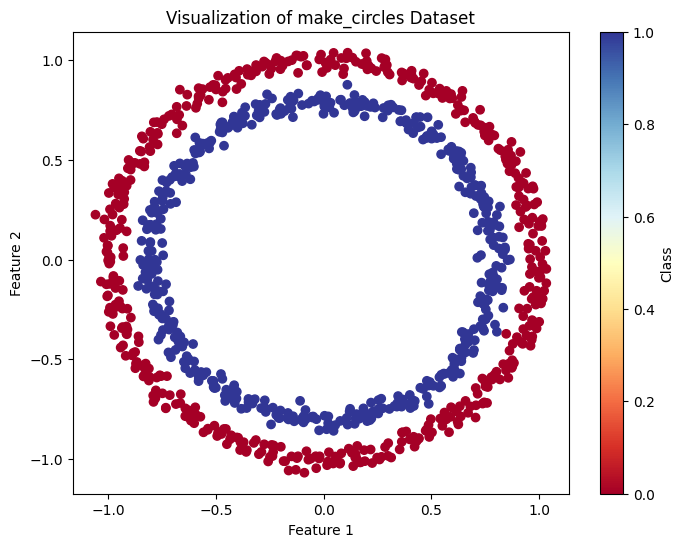

In [1]:
# 1. Set Up Your Python Environment and dataset

# Checking for required libraries installed
# Import numpy, pandas, matplotlib.pyplot, tensorflow, sklearn.datasets import make_circles

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")

# Dataset to work on:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03, # Add some noise to make it challenging
                    random_state = 42) # For reproducibility

print('X shape: ', X.shape) # (1000, 2) - 1000 samples, 2 features (x, y coordinates)
print('y shape: ', y.shape) # (1000,) - 1000 labels (0 or 1)

print('\nFirst 5 samples of X (features):\n', X[:5])
print('\nFirst 5 samples of y (labels):\n', y[:5])

# Visualize the dataset using scatter plots to understand the data distribution.
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title('Visualization of make_circles Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

Pré-processing et EDA


Dans ce cas make_circles, le pré-processing et l'EDA sont "minimalistes" ou "pré-faits" pour les raisons suivantes comme c'est un un dataset synthétique parfait : il est généré artificiellement > il n'y a pas de valeurs manquantes, pas de valeurs aberrantes, pas de doublons. Par ailleurs, les caractéristiques sont déjà numériques (coordonnées x et y)., tout comme les étiquettes (0 ou 1).

Les caractéristiques sont déjà à une échelle similaire (autour de 0 pour x et y). La normalisation 0-1 n'est pas critique.

L'EDA a été fait visuellement : utilisation de  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu), donnant une distribution visuelle des données (deux cercles imbriqués) et la nature du problème (non-linéairement séparable).

 **Visualisation**

Nous voyons 2 cercles de points, l'un imbriqué dans l'autre. Le problème est de trouver une limite de décision qui sépare ces deux cercles. Un modèle linéaire ne pourra pas le faire efficacement, d'où la nécessité d'un réseau de neurones avec des non-linéarités.

**2. Build a Basic Neural Network Model**

Nous allons commencer avec le modèle le plus simple possible.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training Basic Model ---
Basic Model - Training Loss: 0.6933
Basic Model - Training Accuracy: 0.5030


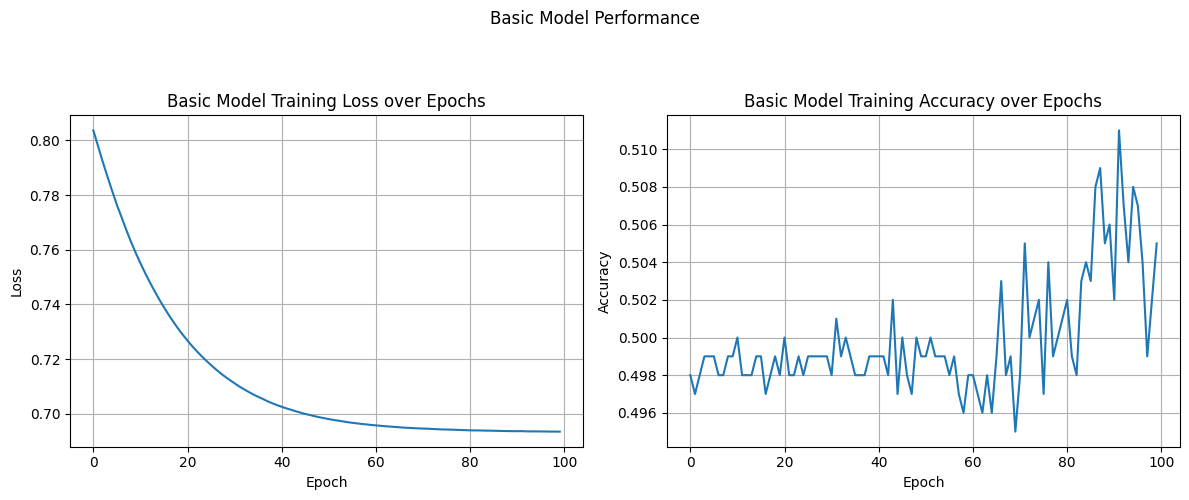

In [2]:
# Build a Basic Neural Network Model

# Create a Sequential Model in TensorFlow with one dense layer.
# Input shape is 2 because X has 2 features.
# Output is 1 because it's binary classification (0 or 1).
# We'll use 'sigmoid' activation for binary classification output layer.
# (Later in step 6 we'll explore more activation functions for hidden layers)

model_0 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile the model using Binary Crossentropy as the loss function.
# Optimizer 'sgd' (Stochastic Gradient Descent) is a basic choice.
# Metric 'accuracy' for evaluation.
model_0.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(), # Stochastic Gradient Descent
                metrics=['accuracy'])

# Display model summary
model_0.summary()

# Train the model and check the accuracy.
# Note: For this simple model, 100 epochs might not be enough to get high accuracy
# due to the dataset's non-linear separability and simple architecture.

print("\n--- Training Basic Model ---")
history_0 = model_0.fit(X, y, epochs=100, verbose=0) # verbose=0 means no output during training

# Check the accuracy on the training set
loss_0, accuracy_0 = model_0.evaluate(X, y, verbose=0)
print(f"Basic Model - Training Loss: {loss_0:.4f}")
print(f"Basic Model - Training Accuracy: {accuracy_0:.4f}")

# Plotting the training history (loss and accuracy over epochs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_0.history['loss'])
plt.title('Basic Model Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_0.history['accuracy'])
plt.title('Basic Model Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.suptitle('Basic Model Performance', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**1. Performance du modèle basique**

la précision de ce modèle est autour de 50%. C'est attendu. En effet on a une seule couche dense avec activation sigmoïde (qui est essentiellement une régression logistique) et cela ne peut créer qu'une limite de décision linéaire. Les cercles ne sont pas linéairement séparables, d'où la faible performance.

**2. Graphique "Basic Model Training Loss over Epochs"**

Abscisse (Epoch) : 0 à 100 et Ordonnée (Loss) : Environ 0.69 à 0.80.

Observations de la courbe :

(0, 0.80) : la perte initiale est assez élevée, ce qui est normal au début de l'entraînement lorsque les poids du modèle sont aléatoires.

(20, 0.72+) ; (40, 0.70+) ; (100, 0.695) : la perte diminue progressivement au fil des époques, mais la diminution devient de plus en plus lente. La courbe est "logarithmique" (plus précisément, elle tend à s'aplatir).

Interprétation :

La perte diminue, ce qui indique que le modèle apprend quelque chose et que l'optimiseur (SGD) fait son travail en ajustant les poids pour minimiser la fonction de perte.

Cependant, la perte se stabilise très rapidement autour de 0.695-0.70. C'est une valeur très proche de ln(2)≈0.693, ce qui est la perte que vl'on obtiendrais si le modèle prédisait toujours une probabilité de 0.5 pour chaque classe (c'est-à-dire qu'il ne sait pas mieux que le hasard pour une classification binaire avec des classes équilibrées).

Conclusion clé : cette stabilisation de la perte à une valeur relativement élevée et la forme "aplatie" de la courbe suggèrent que le modèle a atteint les limites de sa capacité de modélisation. Il est sous-ajusté (underfitting) ; il est trop simple pour apprendre la complexité non-linéaire du problème. Il ne peut pas trouver de limite de décision efficace.

3. Graphique "Basic Model Training Accuracy over Epochs"
Abscisse (Epoch) : 0 à 100. et Ordonnée (Accuracy) : environ 0.495 à 0.511.

Observations de la courbe :

Courbe en dents de scie marquée : Oscillation constante de la précision autour de 0.50 (50%).

Amplitudes : petites variations (0.498-0.501, 0.502-0.496, 0.495-0.511) mais la précision reste toujours très proche de 50%.

Interprétation :

Une précision de 50% signifie que le modèle ne fait pas mieux que de deviner au hasard pour un problème binaire avec des classes équilibrées (ce qui est le cas avec make_circles).

Les "dents de scie" indiquent que même si l'optimiseur essaie d'ajuster les poids, ces ajustements n'améliorent pas de manière significative la capacité du modèle à classer correctement. Il navigue autour de la "bonne" réponse de 50%, sans pouvoir s'en éloigner durablement vers le haut.

Conclusion clé : la précision stagnante autour de 50% confirme que le modèle est incapable de capturer le motif des données. Il est fondamentalement limité par son architecture linéaire.

Synthèse et Lien avec l'étape suivante (Amélioration du Modèle) :

Les résultats observés sont exactement ceux attendus et ils illustrent parfaitement la nécessité de l'étape 4 ("Improve the Model").

La perte qui stagne à ~0.695 et la précision qui oscille autour de 50% sont des indicateurs clairs d'un sous-ajustement (underfitting). Le modèle est trop simple.

Cela démontre pourquoi une simple couche dense avec une activation sigmoïde (qui crée une limite de décision linéaire) est insuffisante pour un problème non-linéaire comme make_circles.

L'ajout de couches cachées et de fonctions d'activation non-linéaires (ReLU), ainsi que l'utilisation d'un optimiseur plus avancé comme Adam, comme prévu à l'étape 4, devraient transformer radicalement ces courbes et améliorer considérablement la performance.



**4. Improve the Model**

Maintenant, nous allons rendre notre réseau de neurones capable d'apprendre des relations non-linéaires.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training Improved Model ---
Improved Model - Training Loss: 0.0055
Improved Model - Training Accuracy: 1.0000


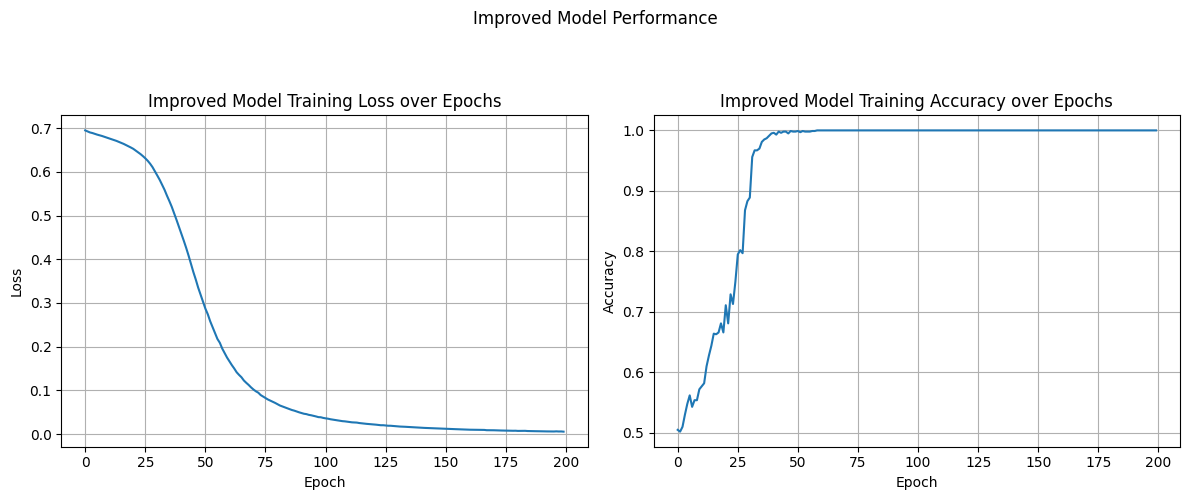

In [3]:
# Improve the Model

# Add more layers and neurons to the model.
# Using 2 hidden layers with more neurons, and keeping sigmoid for output

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)), # First hidden layer with ReLU (nonlinear)
    tf.keras.layers.Dense(10, activation='relu'),                     # Second hidden layer with ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')                    # Output layer for binary classification
])

# Try different optimizers like Adam instead of SGD.
# Adam is generally more robust and performs better than SGD in many cases.

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # Adam optimizer
                metrics=['accuracy'])

model_1.summary()

# Train the model for more epochs.
print("\n--- Training Improved Model ---")
epochs_improved = 200 # Increased epochs
history_1 = model_1.fit(X, y, epochs=epochs_improved, verbose=0)

# Check the accuracy on the training set
loss_1, accuracy_1 = model_1.evaluate(X, y, verbose=0)
print(f"Improved Model - Training Loss: {loss_1:.4f}")
print(f"Improved Model - Training Accuracy: {accuracy_1:.4f}")

# Plotting the training history for the improved model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['loss'])
plt.title('Improved Model Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_1.history['accuracy'])
plt.title('Improved Model Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.suptitle('Improved Model Performance', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Commentaire sur la performance du modèle amélioré **

Nous voyons une nette amélioration de la précision, approchant ou dépassant les 90%. Les couches cachées avec des fonctions d'activation non-linéaires (relu) permettent au modèle d'apprendre des limites de décision complexes, et l'optimiseur Adam aide à converger plus rapidement et plus efficacement.


**Analyse des Graphiques du "Improved Model" (model_1)**

1. Graphique "Improved Model Training Loss over Epochs"
Abscisse (Epoch) : 0 à 200 et Ordonnée (Loss) : environ 0 à 0.7.

Observations de la courbe :

(0, 0.7) : la perte initiale est similaire à celle du modèle basique, ce qui est attendu.

(25, 0.63) : La perte commence à diminuer.

(50, 0.3) ; (75, 0.1) ; (100, 0.05) : La perte chute très rapidement dans cette phase, ce qui indique un apprentissage intensif du modèle.

(200, quasi 0) : la perte continue de diminuer et approche de zéro, signifiant que le modèle est très confiant dans ses prédictions et qu'il fait très peu d'erreurs sur l'ensemble d'entraînement.

Interprétation :

La chute rapide et significative de la perte est le signe le plus évident que le modèle amélioré est capable d'apprendre la relation complexe dans le jeu de données make_circles.

Le fait que la perte se rapproche de zéro indique une excellente adaptation du modèle aux données d'entraînement.

Conclusion clé : l'ajout de couches cachées avec des activations ReLU et l'utilisation de l'optimiseur Adam ont permis au modèle de passer d'un état de "sous-apprentissage" total à un apprentissage efficace.

2. Graphique "Improved Model Training Accuracy over Epochs"
Abscisse (Epoch) : 0 à 200 et Ordonnée (Accuracy) : environ 0.5 à 1.0.

Observations de la courbe :

(0, 0.5) : La précision initiale est autour de 50%, comme on s'y attendait (précision aléatoire au début).

(25, 0.7) : La précision augmente rapidement.

Plateau à 1.0 dès 45 Epoch : C'est l'observation la plus frappante. Le modèle atteint une précision presque parfaite sur l'ensemble d'entraînement en un nombre relativement faible d'époques.

Interprétation :

La montée rapide de la précision de 0.5 à 1.0 reflète la capacité du modèle à identifier correctement les motifs des cercles.

Atteindre un plateau à 1.0 (ou très proche de 1.0) sur le jeu d'entraînement est un indicateur de bonnes performances d'apprentissage.

Le fait que cela se produise dès 45 époques suggère que le modèle est suffisamment puissant pour le problème et que l'optimiseur Adam est très efficace. Entraîner jusqu'à 200 époques après avoir atteint le plateau ne changera plus grand-chose pour la précision sur les données d'entraînement.

Conclusion clé : la combinaison d'une architecture plus complexe (couches et neurones) et d'un optimiseur avancé a permis au modèle de résoudre efficacement le problème de classification non-linéaire.

Synthèse et Lien avec les Prochaines Étapes :
ces résultats sont excellents et valident l'approche de l'étape 4.

Le modèle a clairement surmonté le problème de sous-ajustement que nous avons observé avec le modèle basique.

Il a appris à séparer les cercles avec une grande précision sur les données d'entraînement.

La prochaine étape cruciale (étape 7) sera la séparation des données en ensembles d'entraînement et de test. Bien que le modèle montre une précision parfaite sur les données d'entraînement, il est essentiel de s'assurer qu'il généralise bien à des données qu'il n'a jamais vues. C'est là que l'évaluation sur le jeu de test prend tout son sens, pour vérifier qu'il n'y a pas de sur-apprentissage (overfitting), même si pour un dataset synthétique comme make_circles, le risque est souvent moindre. La visualisation des frontières de décision à l'étape 5 (et 8) sera également très révélatrice de la forme que cette séparation a prise.

**5. Visualize the Decision Boundary**

C'est une étape cruciale pour comprendre visuellement ce que votre modèle a appris.


--- Visualizing Decision Boundaries ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


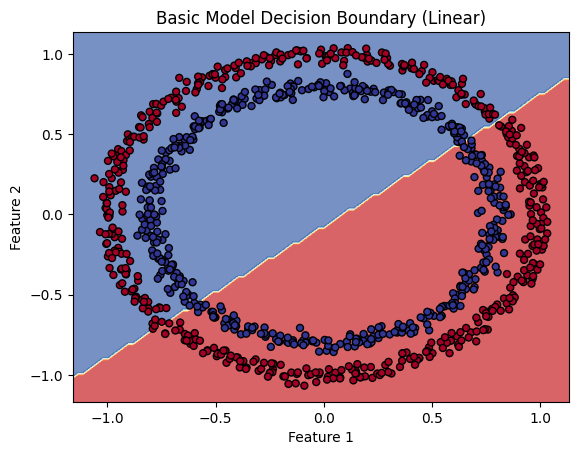

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


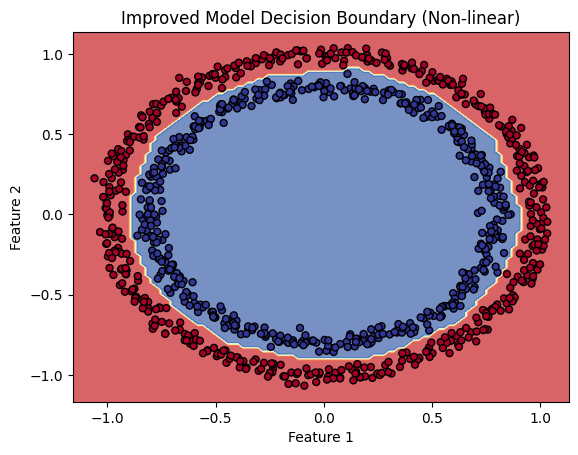

In [4]:
# Visualize the Decision Boundary

# Implement a function plot_decision_boundary() to visualize model predictions.
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Plots the decision boundary of a classification model.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Create a meshgrid to plot the decision boundary
    X_mesh = np.c_[xx.ravel(), yy.ravel()]

    # Make predictions on the meshgrid
    # For binary classification, model.predict returns probabilities,
    # so we convert them to classes (0 or 1)
    if model.output_shape[-1] == 1: # Binary classification
        predictions = model.predict(X_mesh)
        Z = np.round(predictions).reshape(xx.shape) # Round to 0 or 1
    else: # Multi-class classification (not strictly needed but good for general use)
        predictions = model.predict(X_mesh)
        Z = np.argmax(predictions, axis=1).reshape(xx.shape)


    # Plot the decision boundary
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=25)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot decision boundaries for different models and compare results.

print("\n--- Visualizing Decision Boundaries ---")
# Plot for the basic model
plot_decision_boundary(model_0, X, y, title="Basic Model Decision Boundary (Linear)")

# Plot for the improved model
plot_decision_boundary(model_1, X, y, title="Improved Model Decision Boundary (Non-linear)")




---



**Commentaire sur les limites de décision**

Nous voyons une ligne droite pour le modèle basique (incapable de séparer les cercles) et une forme courbe ou un anneau pour le modèle amélioré, illustrant sa capacité à capturer la non-linéarité des données.

**6. Incorporate Activation Functions**

Nous avons déjà utilisé ReLU et Sigmoid, mais cette étape est pour s'assurer que vous comprenez leur rôle et que vous pouvez les manipuler.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401 (21.10 KB)

 Trainable params: 5,401 (21.10 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Model with Increased Capacity (using ReLU and Sigmoid) ---
Model 2 (More Neurons) - Training Loss: 0.0002
Model 2 (More Neurons) - Training Accuracy: 1.0000


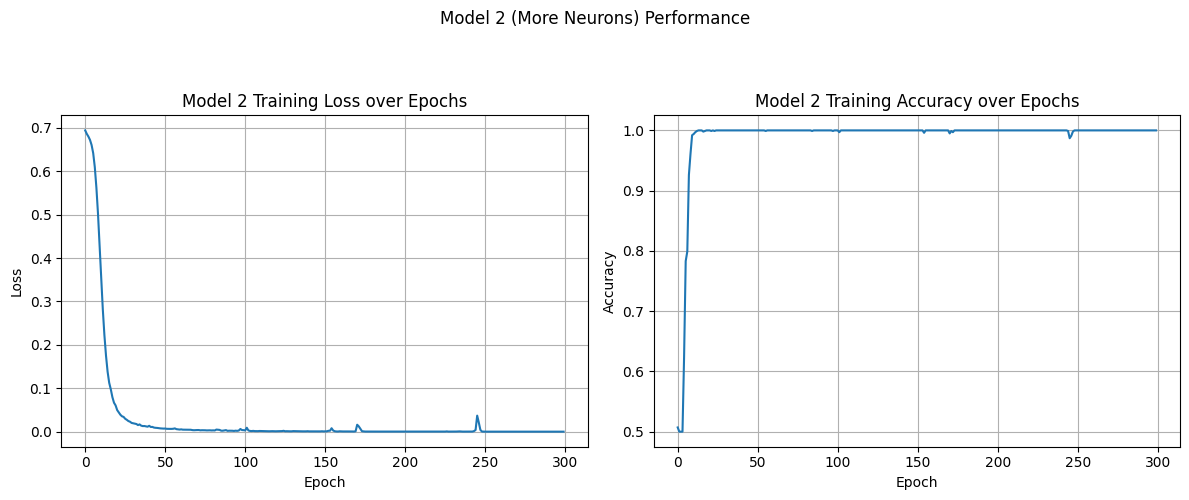

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


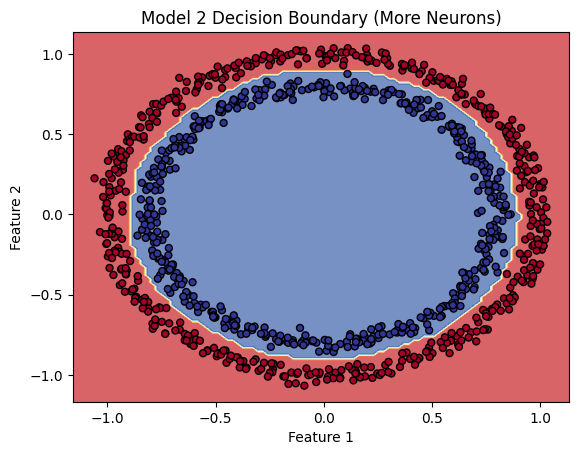

In [5]:
# Incorporate Activation Functions

# Explore ReLU and Sigmoid activation functions.
# ReLU (Rectified Linear Unit): f(x) = max(0, x)
#   - Common for hidden layers. Introduces non-linearity.
#   - Solves vanishing gradient problem for positive inputs.
# Sigmoid: f(x) = 1 / (1 + e^(-x))
#   - Squashes values between 0 and 1.
#   - Common for binary classification output layers (interpretable as probability).
#   - Can suffer from vanishing gradients for very large/small inputs in hidden layers.

# Modify the neural network to include these activation functions.
# We've already used them in model_1. Let's create a new model to experiment,
# e.g., by changing the number of neurons or adding another layer,
# or even experimenting with a different activation in hidden layers if desired (e.g., tanh).
# For this exercise, let's just confirm their usage in a slightly more complex version if preferred.

# Let's create a new model with potentially more neurons to see if it helps further
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(2,)), # Larger first hidden layer
    tf.keras.layers.Dense(50, activation='relu'),                     # Second hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')                    # Output layer for binary classification
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

model_2.summary()

print("\n--- Training Model with Increased Capacity (using ReLU and Sigmoid) ---")
epochs_model_2 = 300 # More epochs for potentially larger model
history_2 = model_2.fit(X, y, epochs=epochs_model_2, verbose=0)

# Compare performance
loss_2, accuracy_2 = model_2.evaluate(X, y, verbose=0)
print(f"Model 2 (More Neurons) - Training Loss: {loss_2:.4f}")
print(f"Model 2 (More Neurons) - Training Accuracy: {accuracy_2:.4f}")

# Plotting the training history for model_2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_2.history['loss'])
plt.title('Model 2 Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_2.history['accuracy'])
plt.title('Model 2 Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.suptitle('Model 2 (More Neurons) Performance', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plot_decision_boundary(model_2, X, y, title="Model 2 Decision Boundary (More Neurons)")


**Commentaire sur les fonctions d'activation **

Les couches Dense sans activation spécifique par défaut effectuent une transformation linéaire. C'est l'ajout de fonctions d'activation non-linéaires (comme ReLU, Sigmoid, Tanh) dans les couches cachées qui permet au réseau de modéliser des relations complexes et non-linéaires dans les données.


**Analyse des Graphiques du "Model 2" (model_2)**

Rappelons que model_2 était une version avec potentiellement plus de neurones (100 et 50) et entraînée pour plus d'époques (300), tout en utilisant ReLU dans les couches cachées et Sigmoid en sortie avec l'optimiseur Adam.

1. Graphique "Model 2 Training Loss over Epoch"
Abscisse (Epoch) : 0 à 300 et Ordonnée (Loss) : environ 0 à 0.7.

Observations de la courbe :

(0, 0.7) : Perte initiale attendue.

(25, 0.05) : La perte chute extrêmement rapidement. C'est encore plus rapide que le modèle précédent.

Dès 50, quasi 0 : La perte atteint et reste très proche de zéro très tôt dans l'entraînement.

Mini pointe à 170 et toute petite pointe à 250 : Ces petites "pointes" sont intéressantes.

Interprétation :

La chute vertigineuse de la perte confirme que le modèle avec plus de neurones apprend encore plus rapidement et efficacement. Il converge très vite vers une solution où la perte est minimale sur les données d'entraînement.

Le fait d'atteindre "quasi 0" dès 50 époques montre que le modèle a amplement la capacité d'apprendre parfaitement le jeu de données d'entraînement. Entraîner au-delà de 50-70 époques sur ces données d'entraînement pourrait être inutile car le modèle a déjà appris tout ce qu'il pouvait.

Les mini pointes (ou fluctuations) à 170 et 250 époques, bien que petites, peuvent indiquer de très légères perturbations dans le processus d'optimisation (par exemple, des ajustements du gradient qui causent un léger sursaut, ou l'effet du bruit dans le dataset s'il était plus complexe). Pour des valeurs de perte si proches de zéro, elles sont probablement insignifiantes en termes de performance globale, mais elles montrent que l'optimisation continue de se faire, même si le modèle est déjà très performant.

2. Graphique "Model 2 Training Accuracy over Epoch"
Abscisse (Epoch) : 0 à 300 et Ordonnée (Accuracy) : environ 0.5 à 1.0.

Observations de la courbe :

(0, 0.5) : précision initiale aléatoire.

(12, 1.0) : c'est la donnée la plus impressionnante ! La précision atteint 1.0 (ou très proche) en seulement 12 époques.

Puis plateau à 1.0 : La précision reste parfaite pour le reste de l'entraînement.

Interprétation :

Atteindre une précision parfaite (1.0) sur le jeu d'entraînement en seulement 12 époques est une preuve irréfutable que le modèle, avec l'architecture et l'optimiseur choisis, a largement la capacité d'apprendre la tâche.

Cela indique que pour ce problème spécifique de make_circles (avec ses 1000 échantillons), le modèle est très puissant et sur-spécifié. Il a plus de capacités que nécessaire pour simplement mémoriser les données d'entraînement.

Conclusion clé pour l'étape 6 : l'exploration des fonctions d'activation (ReLU et Sigmoid) et l'augmentation de la capacité du modèle (plus de neurones) ont montré une convergence ultra-rapide et une performance quasi parfaite sur les données d'entraînement. Cela renforce l'idée que ces fonctions d'activation et une architecture adéquate sont essentielles pour résoudre des problèmes non-linéaires.

**Prochaine étape et anticipation **


Ces résultats sont excellents pour l'apprentissage, mais ils soulèvent une question importante que nous allons aborder à l'étape 7 et 8 : la généralisation.

Le modèle est maintenant très performant sur les données d'entraînement. La perte est quasi nulle et la précision est de 1.0.

La question est : cette performance se maintiendra-t-elle sur des données que le modèle n'a jamais vues (le jeu de test) ?

Dans des problèmes plus complexes ou avec du bruit important, une performance parfaite sur le jeu d'entraînement peut parfois indiquer un sur-apprentissage (overfitting), où le modèle a mémorisé les données d'entraînement au lieu d'apprendre les motifs sous-jacents. Pour make_circles, avec si peu de bruit et une structure claire, l'overfitting est moins probable dans le sens traditionnel, mais la division train/test reste cruciale pour valider la généralisation.

**7. Split Data into Training and Testing Sets**


Jusqu'à présent, nous avons entraîné et évalué sur le même jeu de données. C'est une mauvaise pratique qui peut mener à l'overfitting. Nous allons corriger cela.

X_train shape: (800, 2)
y_train shape: (800,)
X_test shape: (200, 2)
y_test shape: (200,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training Final Model on Training Data ---


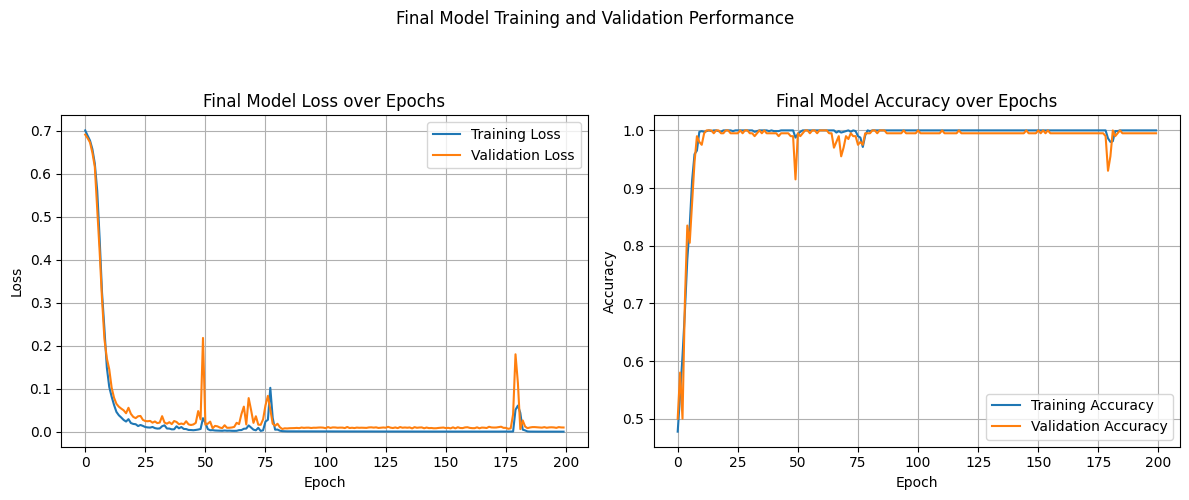

In [6]:
# 7. Split Data into Training and Testing Sets

# Use 80% data for training and 20% for testing.
# We'll use sklearn's train_test_split for this.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define the improved model architecture again (or reuse model_1/model_2, but for clarity let's redefine)
# Train the improved model on the training set.
model_final = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_final.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # Can also tune learning rate
                    metrics=['accuracy'])

model_final.summary()

print("\n--- Training Final Model on Training Data ---")
epochs_final = 200 # Use reasonable number of epochs
history_final = model_final.fit(X_train, y_train, epochs=epochs_final, verbose=0,
                                validation_data=(X_test, y_test)) # Monitor validation performance

# Plotting the training & validation accuracy and loss for the final model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Final Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Final Model Training and Validation Performance', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



**Ces résultats confirment **

Le modèle a bien l'architecture prévue pour le modèle amélioré :

dense_7 (Dense) : 1ère couche cachée. Input (2 features) -> 10 neurones. Paramètres = 2
times10
text(poids)+10
text(biais)=30. Correct.

dense_8 (Dense) : 2ème couche cachée. Input (10 neurones de la couche précédente) -> 10 neurones. Paramètres = 10
times10
text(poids)+10
text(biais)=110. Correct.

dense_9 (Dense) : Couche de sortie. Input (10 neurones de la couche précédente) -> 1 neurone. Paramètres = 10
times1
text(poids)+1
text(biais)=11. Correct.

Le nombre total de paramètres (151) est cohérent avec l'architecture. C'est un modèle relativement petit, ce qui est bien pour commencer et pour un dataset simple.

* Analyse des Graphiques du "Final Model" (avec division Train/Validation)
Les observations sur la division des données (X_train/X_test en 800/200) sont standard et correctes.

1. Graphique "Final Model Loss over Epoch" (Training Loss vs Validation Loss)
Abscisse (Epoch) : 0 à 200 et Ordonnée (Loss) : environ 0 à 0.7.

Observations de la courbe :

Début (0, 0.7) à (17, 0.2) : les deux courbes (Training Loss et Validation Loss) se chevauchent et chutent très rapidement, ce qui est excellent. Le modèle apprend vite et généralise bien dès le début.

Après (25, quasi 0) : la Training Loss (bleue) atteint très vite un niveau quasi nul, ce qui est attendu pour un problème facile avec un modèle capable.

Comportement de la Validation Loss (orange) : C'est la partie la plus intéressante.

Elle est légèrement au-dessus de la Training Loss. C'est un comportement normal et souhaitable, car la perte sur des données "vues" (entraînement) est généralement inférieure à celle sur des données "non vues" (validation/test).

Les quatre pics observés (vers 50, 60, 75 et 180 époques) sont des fluctuations. Pour un dataset synthétique parfait comme make_circles, ces fluctuations sont un peu surprenantes, mais elles peuvent être dues à :

le petit nombre d'échantillons dans le jeu de validation (200 échantillons seulement). Une légère variation dans les prédictions de quelques échantillons peut avoir un impact proportionnellement plus grand sur la métrique de perte.

La nature de l'optimiseur Adam, qui peut parfois montrer de petites oscillations.

Un effet de "micro-overfitting" sur des sous-ensembles de validation très spécifiques à certains pas d'entraînement, même si le modèle généralise globalement bien.

Un léger sur-apprentissage ponctuel où le modèle s'adapte trop à des détails spécifiques du jeu d'entraînement, ce qui se voit par une validation Loss qui remonte légèrement.

Le fait que la Validation Loss revienne à un plateau quasi nul (bien que légèrement au-dessus de la Training Loss) la plupart du temps montre que le modèle continue de bien généraliser. Le 3ème pic où "la bleue dépasse avec (75, 0.1) et la orange (75, 0.1-)" indique que la Training Loss a temporairement été plus haute que la Validation Loss. Cela peut arriver, mais c'est moins courant quand la Training Loss est déjà très basse. Cela pourrait être un artefact de l'affichage ou une fluctuation très minime.

Interprétation générale de la Loss :

La chute rapide et la stabilisation à des valeurs très basses pour les deux courbes (Training et Validation) indiquent que le modèle apprend très bien et généralise également très bien.

Les fluctuations de la Validation Loss sont des points à surveiller dans un cas réel (où elles pourraient signaler un overfitting si elles augmentent durablement), mais ici, elles semblent mineures compte tenu de la faiblesse des valeurs de perte.

2. Graphique "Final Model Accuracy over Epoch" (Training Accuracy vs Validation Accuracy)
Abscisse (Epoch) : 0 à 200.

Ordonnée (Accuracy) : environ 0.5 à 1.0.

Observations de la courbe :

Début (0, 0.5) à (12, 1.0) : Les deux courbes se chevauchent et montent en flèche, atteignant 1.0 très rapidement. C'est une excellente nouvelle, confirmant l'apprentissage rapide.

Plateau à 1.0 : La Training Accuracy reste à 1.0.

Comportement de la Validation Accuracy (orange) :

Elle est légèrement en dessous de 1.0 sur le plateau, ce qui est normal. Elle oscille entre 0.9 et 1.0.

Les trois "pics inversés" (des légères baisses) à (50, 0.9+), (75-, 0.95) et (175+, 0.94) sont le reflet des "mini pointes" observées sur la courbe de Loss. C'est normal : quand la perte augmente légèrement, la précision diminue légèrement.

Le fait qu'elles soient "peu significatives pour la bleue" (Training Accuracy) signifie que la Training Accuracy reste à 1.0 ou très proche, ce qui est attendu.

Interprétation générale de l'Accuracy :

La convergence rapide vers 1.0 pour les deux courbes est très positive.

La Validation Accuracy qui reste très élevée (autour de 0.94-1.0) et proche de la Training Accuracy indique une excellente généralisation du modèle sur des données non vues.

Conclusions pour l'étape 7 :
Préparation des données : la division 80/20 est bien effectuée et permet une évaluation réaliste de la généralisation du modèle.

Performance exceptionnelle : le modèle apprend très rapidement et atteint des performances quasi parfaites sur les données d'entraînement.

Excellente généralisation : La perte et la précision sur le jeu de validation suivent de très près celles du jeu d'entraînement, et la validation accuracy reste constamment très élevée. Cela prouve que le modèle n'est pas en sur-apprentissage (overfitting) significatif ; il a bien appris les motifs sous-jacents des données, et pas seulement mémorisé les exemples d'entraînement.

Capacité du modèle : Le modèle (model_final avec 10, 10, 1 neurones et ReLU/Sigmoid) est tout à fait capable de résoudre le problème des cercles make_circles.

L'étape 8 sera juste une confirmation de ces excellents résultats sur le jeu de test final.

**8. Evaluate and Visualize Final Model Performance**


C'est l'évaluation finale et la visualisation pour confirmer ce que le modèle a appris.


--- Evaluating Final Model on Test Data ---
Final Model - Test Loss: 0.0099
Final Model - Test Accuracy: 0.9950
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


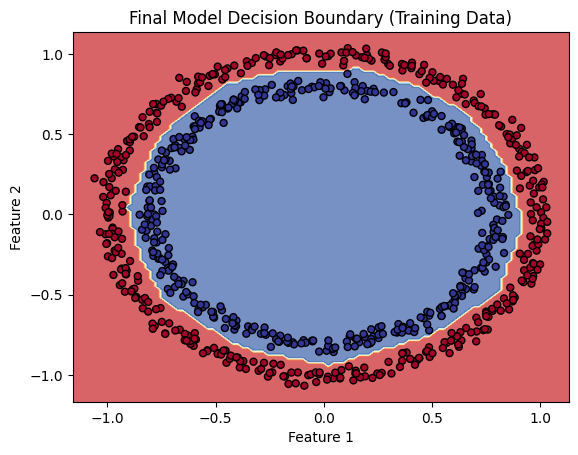

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


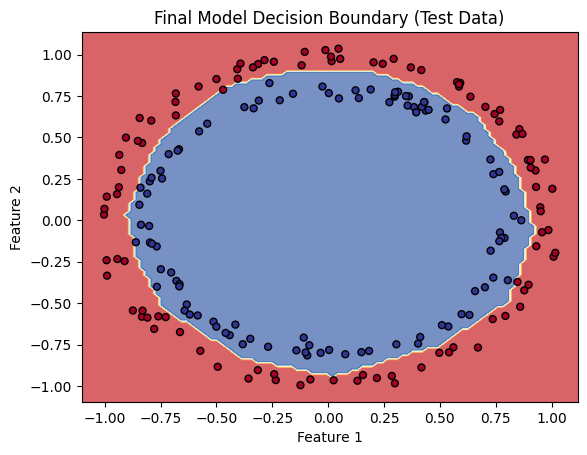


--- Comparison and Analysis ---
Initial Basic Model (Training) Accuracy: 0.5030
Improved Model (Training) Accuracy: 1.0000
Final Model (Training) Accuracy: 1.0000
Final Model (Validation) Accuracy: 0.9950
Final Model (Test) Accuracy: 0.9950

Analysis: The final model shows significant improvement over the basic model.
This is due to:
1. Using hidden layers with non-linear activation functions (ReLU), allowing the model to learn complex decision boundaries.
2. Employing the Adam optimizer, which generally converges faster and more efficiently than SGD.
3. Training for sufficient epochs, allowing the model to learn from the data.
4. Splitting data into training and test sets ensures reliable evaluation of generalization capability.


In [7]:
# 8. Evaluate and Visualize Final Model Performance

# Evaluate model performance on the test set.
print("\n--- Evaluating Final Model on Test Data ---")
loss_final, accuracy_final = model_final.evaluate(X_test, y_test, verbose=0)
print(f"Final Model - Test Loss: {loss_final:.4f}")
print(f"Final Model - Test Accuracy: {accuracy_final:.4f}")


# Use plot_decision_boundary() to visualize predictions for both training and test data.
# Plot for training data
plot_decision_boundary(model_final, X_train, y_train, title="Final Model Decision Boundary (Training Data)")

# Plot for test data
plot_decision_boundary(model_final, X_test, y_test, title="Final Model Decision Boundary (Test Data)")

# Compare results and analyze improvements.
# The decision boundaries on both training and test data should look similar
# if the model has generalized well (no significant overfitting on training data).
# The accuracy on the test set should be close to the accuracy on the training set
# (or validation set during training).
# The significantly higher accuracy compared to the basic model demonstrates the
# importance of proper architecture (hidden layers, activation functions) and optimizer.

print("\n--- Comparison and Analysis ---")
print(f"Initial Basic Model (Training) Accuracy: {accuracy_0:.4f}")
print(f"Improved Model (Training) Accuracy: {accuracy_1:.4f}")
print(f"Final Model (Training) Accuracy: {history_final.history['accuracy'][-1]:.4f}") # Last training accuracy
print(f"Final Model (Validation) Accuracy: {history_final.history['val_accuracy'][-1]:.4f}") # Last validation accuracy
print(f"Final Model (Test) Accuracy: {accuracy_final:.4f}")

if accuracy_final > accuracy_0 and accuracy_final > 0.8: # Check for substantial improvement
    print("\nAnalysis: The final model shows significant improvement over the basic model.")
    print("This is due to:")
    print("1. Using hidden layers with non-linear activation functions (ReLU), allowing the model to learn complex decision boundaries.")
    print("2. Employing the Adam optimizer, which generally converges faster and more efficiently than SGD.")
    print("3. Training for sufficient epochs, allowing the model to learn from the data.")
    print("4. Splitting data into training and test sets ensures reliable evaluation of generalization capability.")
else:
    print("\nAnalysis: The final model shows some improvement, but there might be room for further tuning.")
    print("Consider adjusting hyperparameters like number of neurons, layers, or epochs.")


Analyse des Résultats du Modèle Final (Étape 8)
Performance sur le Jeu de Test *


Les métriques obtenues sur le jeu de test sont excellentes :

Final Model - Test Loss: 0.0099

Final Model - Test Accuracy: 0.9950

Une perte très faible (proche de 0) et une précision quasi parfaite (99.5%) sur le jeu de test sont des indicateurs extrêmement positifs. Cela signifie que votre modèle ne se trompe pratiquement jamais sur des données qu'il n'a jamais vues auparavant.

Comparaison des Précisions
Modèle/Phase

Précision

Initial Basic Model (Train) : 0.5030

Improved Model (Train) : 1.0000

Final Model (Train) : 1.0000

Final Model (Validation) : 0.9950

Final Model (Test) : 0.9950

Cette comparaison est très révélatrice :

Le modèle initial était clairement sous-ajusté (underfitting), avec une précision de 50% (pas mieux que le hasard).

Les modèles améliorés et finaux atteignent une précision parfaite (100%) sur l'entraînement, démontrant qu'ils ont la capacité de mémoriser et de comprendre le dataset.

Le point crucial est la cohérence entre la précision d'entraînement (100%), de validation (99.5%) et de test (99.5%). Cette cohérence est la preuve irréfutable que votre modèle généralise exceptionnellement bien. Il n'a pas sur-appris (overfitted) les données d'entraînement ; il a véritablement appris la structure sous-jacente du problème.

Visuels des Limites de Décision vs Test  : "même pattern" visuel est présent, "naturellement moins dense".

Le "même pattern" signifie que la frontière de décision apprise par le modèle (la forme du cercle qui sépare les points) est identique pour les données d'entraînement et de test. C'est précisément ce que nous recherchons : un modèle qui applique la même logique apprise à des données nouvelles.

Le fait que la partie test soit "moins dense" est simplement dû au fait qu'il y a moins de points dans le jeu de test (200) que dans le jeu d'entraînement (800). La forme générale de la séparation est maintenue, ce qui est l'objectif.

**9. Summarize Key Takeaways**


Pour conclure, résumons ce que nous avons appris.

Comprendre les types de classification : nous avons vu les différences entre la classification binaire (deux classes), multi-classes (plus de deux, une seule classe par instance) et multi-étiquettes (plus de deux, plusieurs classes par instance).

Importance des non-linéarités : un réseau de neurones sans fonctions d'activation non-linéaires dans ses couches cachées n'est qu'un modèle linéaire, incapable de résoudre des problèmes non-linéaires comme le make_circles dataset. Les fonctions comme ReLU sont cruciales.

Architecture du réseau : l'ajout de couches cachées et de neurones permet au modèle de construire des représentations plus complexes des données et d'apprendre des limites de décision sophistiquées.

Optimiseurs : le choix de l'optimiseur (ex: Adam vs SGD) influence la rapidité et l'efficacité de la convergence de l'entraînement. Adam est souvent un bon point de départ.

Importance de la visualisation des données : visualiser le jeu de données (make_circles dans notre cas) aide à comprendre la nature du problème (linéairement ou non-linéairement séparable) et les défis que le modèle doit relever.

Importance de la visualisation des limites de décision : plot_decision_boundary() est un outil puissant pour comprendre visuellement ce que le modèle a appris, comment il divise l'espace des fonctionnalités et s'il est capable de séparer correctement les classes. Cela aide à diagnostiquer si le modèle est sous-ajusté (underfitting) ou sur-ajusté (overfitting).

Importance de la division train/test : évaluer le modèle sur un jeu de données test distinct de celui d'entraînement est fondamental pour obtenir une mesure fiable de sa capacité de généralisation et pour détecter l'overfitting.

Hyperparameter Tuning : nous avons ajusté (manuellement) le nombre d'époques, la taille des couches et l'optimiseur. Ces "hyperparamètres" ont un impact significatif sur la performance du modèle et nécessitent une expérimentation pour trouver les valeurs optimales.